# ScaleMAP peak-fit analysis

Flow: **files → parameters → load → QC → preprocess → UMAP → dashboard →
background mask → masked UMAP → final dashboard → peak explorer → kmeans →
cluster explorer**.  Runs top-to-bottom in a fresh kernel.

`ANALYSIS_MODE='peak_params'` embeds each pixel's *set of fitted peaks* via a
canonical pseudo-Voigt descriptor (`build_peak_descriptor` →
`normalize_peak_descriptor` → `UMAP(metric=PEAK_METRIC,
random_state=RANDOM_STATE)`).  `ANALYSIS_MODE='spectral'` keeps the
`spectral_concat → zscore_normalize` path.

**Comparing images in one embedding space** (conserved embedding): run image 1
with `EMBED_ROLE='fit_reference'` — this persists a reference bundle. Then for
image 2 (any size, any mask), set the *files* cell to the new file, set
`EMBED_ROLE='transform_into_reference'`, and point `REFERENCE_BUNDLE_PATH` at
image 1's bundle: image 2's pixels are placed into image 1's embedding frame
by peak profile, without refitting. No image splicing needed.

**Pen scoping**: pens 1–2 draw on the *embedding* panel, pens 3–4 on the
*image* panel. Pen 1 strokes/spectra are blue, pen 2 orange. Cross-highlights:
embedding pens paint the image blue (pen 1) / red (pen 2); image
pens paint the embedding blue (pen 3) / red (pen 4).

In [18]:
# === Files & role (edit per image) ==========================================
H5_FILE_PATH = r'/Volumes/edrive/bcars-imaging/shi/2025.09.15/peak-fit-pub/fitted_differentiated_segmented.h5'   # CASCADE HDF5 output
PICKLE_FILE_PATH = None             # CRIkit .pickle export (spectral mode only; None if using H5)
ANALYSIS_MODE = 'peak_params'       # 'peak_params' or 'spectral'
SAVEFILE_BASENAME = 'differentiated-peakfit'

# Cross-image embedding role for this run:
#   'fit_reference'             — fit THIS image and persist its bundle
#   'transform_into_reference'  — place THIS image into an existing frame
EMBED_ROLE = 'transform_into_reference'
# None -> derive from SAVEFILE_BASENAME (normal for fit_reference).
# For transform_into_reference, set this to the REFERENCE image's bundle path,
# e.g. r'undifferentiated-peakfit_reference_bundle_fg.dill'.
REFERENCE_BUNDLE_PATH = r'differentiated-peakfit_reference_bundle_fg.dill'
TRANSFORM_BACKEND = 'aligned'       # 'parametric' (needs TensorFlow) | 'aligned'

In [19]:
# === Analysis parameters =====================================================
import os
import numpy as np

MASK_MODE = 'exclude_background'    # 'exclude_background' or 'include_foreground'
SKIP_BACKGROUND_STEP = True         # True for pre-segmented CASCADE images

# Reproducibility — every UMAP construction is seeded with this.
RANDOM_STATE = 42

# UMAP hyperparameters
UMAP_N_NEIGHBORS = 15
UMAP_MIN_DIST = 0.1
UMAP_N_EPOCHS = 200
UMAP_DENSMAP = True
UMAP_DENS_FRAC = 1.0

# --- Peak-fit path (ANALYSIS_MODE='peak_params') ---------------------------
# Canonical wavenumber grid (cm^-1) shared by ALL pixels and ALL images that
# are to be compared or co-embedded. Never derived from a particular image.
DESCRIPTOR_GRID = np.arange(400.0, 3400.0, 2.0)
AMP_THRESHOLD = 1e-3                # CASCADE production default; slots below are zero-padding
SIGMA_RENDER = 'fitted'             # 'fitted' (use fitted sigma/gamma) or a positive float (fixed Gaussian sigma)
PEAK_NORM_MODE = 'l1_per_pixel'     # 'l1_per_pixel' | 'reference' | 'none'
PEAK_METRIC = 'cosine'              # standard named metric ('euclidean' also selectable)

# Pixels with ZERO real peaks (all amplitudes <= AMP_THRESHOLD) are segmented
# background in CASCADE output; exclude them from every analysis pass.
EXCLUDE_ZERO_PEAK_PIXELS = True

# Foreground tag keeps caches/bundles fit on foreground-only pixels from
# colliding with older full-image fits.
_FG_TAG = '_fg' if (ANALYSIS_MODE == 'peak_params' and EXCLUDE_ZERO_PEAK_PIXELS) else ''
if REFERENCE_BUNDLE_PATH is None:
    REFERENCE_BUNDLE_PATH = f'{SAVEFILE_BASENAME}_reference_bundle{_FG_TAG}.dill'

# Masked (second-pass) reference bundle, derived from the reference bundle
# path so a fit and a transform can never collide.
_bundle_root, _bundle_ext = os.path.splitext(REFERENCE_BUNDLE_PATH)
REFERENCE_BUNDLE_MASKED_PATH = f'{_bundle_root}_masked{_bundle_ext or ".dill"}'

# --- Spectral path (ANALYSIS_MODE='spectral') ------------------------------
# Ranges are WAVENUMBER VALUES (cm^-1). Matches the original template:
# fingerprint (600-1750), then SKIP the noisy silent region (1750-2750),
# then the CH stretch (2750-3250) attenuated x0.1 so its naturally larger
# peaks don't dominate the separation. Ranges outside the measured axis
# (e.g. the CH range for a peak-fit .h5 that stops near 1800) are dropped
# automatically at preprocess time.
SPECTRAL_RANGES = [(600.0, 1750.0), (2750.0, 3250.0)]
SPECTRAL_SCALE_FACTORS = [1.0, 0.1]
ZSCORE_EPSILON = 1e-8

# --- QC ----------------------------------------------------------------------
QC_WAVENUMBER = 1004.0              # cm^-1 channel to display (None -> middle channel)
QC_CONTRAST_PERCENTILES = (2.0, 98.0)

# --- Clustering -------------------------------------------------------------
N_CLUSTERS = 5                      # static (publication) KMeans below
N_CLUSTERS_EXPLORER = 5             # starting k for the interactive explorer
KMEANS_FEATURES = 'descriptor'      # 'descriptor' (peaks) | 'model_cube' (spectra) | 'embedding'
KMEANS_CLIP_PERCENTILES = (1.0, 99.0)  # robust clip for model_cube features

<img src='data:image/png;base64,iVBORw0KGgoAAAANSUhEUgAAAEAAAABACAYAAACqaXHeAAAABHNCSVQICAgIfAhkiAAAAAlwSFlz
AAAB+wAAAfsBxc2miwAAABl0RVh0U29mdHdhcmUAd3d3Lmlua3NjYXBlLm9yZ5vuPBoAAA6zSURB
VHic7ZtpeFRVmsf/5966taWqUlUJ2UioBBJiIBAwCZtog9IOgjqACsogKtqirT2ttt069nQ/zDzt
tI4+CrJIREFaFgWhBXpUNhHZQoKBkIUASchWla1S+3ar7r1nPkDaCAnZKoQP/D7mnPOe9/xy76n3
nFSAW9ziFoPFNED2LLK5wcyBDObkb8ZkxuaoSYlI6ZcOKq1eWFdedqNzGHQBk9RMEwFAASkk0Xw3
ETacDNi2vtvc7L0ROdw0AjoSotQVkKSvHQz/wRO1lScGModBFbDMaNRN1A4tUBCS3lk7BWhQkgpD
lG4852/+7DWr1R3uHAZVQDsbh6ZPN7CyxUrCzJMRouusj0ipRwD2uKm0Zn5d2dFwzX1TCGhnmdGo
G62Nna+isiUqhkzuKrkQaJlPEv5mFl2fvGg2t/VnzkEV8F5ioioOEWkLG86fvbpthynjdhXYZziQ
x1hC9J2NFyi8vCTt91Fh04KGip0AaG9zuCk2wQCVyoNU3Hjezee9bq92duzzTmxsRJoy+jEZZZYo
GTKJ6SJngdJqAfRzpze0+jHreUtPc7gpBLQnIYK6BYp/uGhw9YK688eu7v95ysgshcg9qSLMo3JC
4jqLKQFBgdKDPoQ+Pltb8dUyQLpeDjeVgI6EgLIQFT5tEl3rn2losHVsexbZ3EyT9wE1uGdkIPcy
BGxn8QUq1QrA5nqW5i2tLqvrrM9NK6AdkVIvL9E9bZL/oyfMVd/jqvc8LylzRBKDJSzIExwhQzuL
QYGQj4rHfFTc8mUdu3E7yoLtbTe9gI4EqVgVkug2i5+uXGo919ixbRog+3fTbQ8qJe4ZOYNfMoTI
OoshUNosgO60AisX15aeI2PSIp5KiFLI9ubb1vV3Qb2ltwLakUCDAkWX7/nHKRmmGIl9VgYsUhJm
2NXjKYADtM1ygne9QQDIXlk49FBstMKx66D1v4+XuQr7vqTe0VcBHQlRWiOCbmmSYe2SqtL6q5rJ
zsTb7lKx3FKOYC4DoqyS/B5bvLPxvD9Qtf6saxYLQGJErmDOdOMr/zo96km1nElr8bmPOBwI9COv
HnFPRIwmkSOv9kcAS4heRsidOkpeWBgZM+UBrTFAXNYL5Vf2ii9c1trNzpYdaoVil3WIc+wdk+gQ
noie3ecCcxt9ITcLAPWt/laGEO/9U6PmzZkenTtsSMQ8uYywJVW+grCstAvCIaAdArAsIWkRDDs/
KzLm2YcjY1Lv0UdW73HabE9n6V66cxSzfEmuJssTpKGVp+0vHq73FwL46eOjpMpbRAnNmJFrGJNu
Ukf9Yrz+3rghiumCKNXXWPhLYcjxGsIpoCMsIRoFITkW8AuyM8jC1+/QLx4bozCEJIq38+1rtpR6
V/yzb8eBlRb3fo5l783N0CWolAzJHaVNzkrTzlEp2bQ2q3TC5gn6wpnoQAmwSiGh2GitnTmVMc5O
UyfKWUKCIsU7+fZDKwqdT6DDpvkzAX4/+AMFjk0tDp5GRXLpQ2MUmhgDp5gxQT8+Y7hyPsMi8uxF
71H0oebujHALECjFKaW9Lm68n18wXp2kVzIcABytD5iXFzg+WVXkegpAsOOYziqo0OkK76GyquC3
ltZAzMhhqlSNmmWTE5T6e3IN05ITFLM4GdN0vtZ3ob8Jh1NAKXFbm5PtLU/eqTSlGjkNAJjdgn/N
aedXa0tdi7+t9G0FIF49rtMSEgAs1kDLkTPO7ebm4IUWeyh1bKomXqlgMG6kJmHcSM0clYLJ8XtR
1GTnbV3F6I5wCGikAb402npp1h1s7LQUZZSMIfALFOuL3UUrfnS8+rez7v9qcold5tilgHbO1fjK
9ubb17u9oshxzMiUBKXWqJNxd+fqb0tLVs4lILFnK71H0Ind7uiPgACVcFJlrb0tV6DzxqqTIhUM
CwDf1/rrVhTa33/3pGPxJYdQ2l2cbgVcQSosdx8uqnDtbGjh9SlDVSMNWhlnilfqZk42Th2ZpLpf
xrHec5e815zrr0dfBZSwzkZfqsv+1FS1KUknUwPARVvItfKUY+cn57yP7qv07UE3p8B2uhUwLk09
e0SCOrK+hbdYHYLjRIl71wWzv9jpEoeOHhGRrJAzyEyNiJuUqX0g2sBN5kGK6y2Blp5M3lsB9Qh4
y2Ja6x6+i0ucmKgwMATwhSjdUu49tKrQ/pvN5d53ml2CGwCmJipmKjgmyuaXzNeL2a0AkQ01Th5j
2DktO3Jyk8f9vcOBQHV94OK+fPumJmvQHxJoWkaKWq9Vs+yUsbq0zGT1I4RgeH2b5wef7+c7bl8F
eKgoHVVZa8ZPEORzR6sT1BzDUAD/d9F78e2Tzv99v8D+fLVTqAKAsbGamKey1Mt9Ann4eH3gTXTz
idWtAJ8PQWOk7NzSeQn/OTHDuEikVF1R4z8BQCy+6D1aWRfY0tTGG2OM8rRoPaeIj5ZHzJxszElN
VM8K8JS5WOfv8mzRnQAKoEhmt8gyPM4lU9SmBK1MCQBnW4KONT86v1hZ1PbwSXPw4JWussVjtH9Y
NCoiL9UoH/6PSu8jFrfY2t36erQHXLIEakMi1SydmzB31h3GGXFDFNPaK8Rme9B79Ixrd0WN+1ij
NRQ/doRmuFLBkHSTOm5GruG+pFjFdAmorG4IXH1Qua6ASniclfFtDYt+oUjKipPrCQB7QBQ2lrgP
fFzm+9XWUtcqJ3/5vDLDpJ79XHZk3u8nGZ42qlj1+ydtbxysCezrydp6ugmipNJ7WBPB5tydY0jP
HaVNzs3QzeE4ZpTbI+ZbnSFPbVOw9vsfnVvqWnirPyCNGD08IlqtYkh2hjZ5dErEQzoNm+6ykyOt
Lt5/PQEuSRRKo22VkydK+vvS1XEKlhCJAnsqvcVvH7f/ZU2R67eXbMEGAMiIV5oWZWiWvz5Fv2xG
sjqNJQRvn3Rs2lji/lNP19VjAQDgD7FHhujZB9OGqYxRkZxixgRDVlqS6uEOFaJUVu0rPFzctrnF
JqijImVp8dEKVWyUXDk92zAuMZ6bFwpBU1HrOw6AdhQgUooChb0+ItMbWJitSo5Ws3IAOGEOtL53
0vHZih9sC4vtofZ7Qu6523V/fmGcds1TY3V36pUsBwAbSlxnVh2xLfAD/IAIMDf7XYIkNmXfpp2l
18rkAJAy9HKFaIr/qULkeQQKy9zf1JgDB2uaeFNGijo5QsUyacNUUTOnGO42xSnv4oOwpDi1zYkc
efUc3I5Gk6PhyTuVKaOGyLUAYPGIoY9Pu/atL/L92+4q9wbflRJ2Trpm/jPjdBtfnqB/dIThcl8A
KG7hbRuKnb8qsQsVvVlTrwQAQMUlf3kwJI24Z4JhPMtcfng5GcH49GsrxJpGvvHIaeem2ma+KSjQ
lIwUdYyCY8j4dE1KzijNnIP2llF2wcXNnsoapw9XxsgYAl6k+KzUXbi2yP3KR2ecf6z3BFsBICdW
nvnIaG3eHybqX7vbpEqUMT+9OL4Qpe8VON7dXuFd39v19FoAABRVePbGGuXTszO0P7tu6lghUonE
llRdrhArLvmKdh9u29jcFiRRkfLUxBiFNiqSU9icoZQHo5mYBI1MBgBH6wMNb+U7Pnw337H4gi1Y
ciWs+uks3Z9fztUvfzxTm9Ne8XXkvQLHNytOOZeiD4e0PgkAIAYCYknKUNUDSXEKzdWNpnil7r4p
xqkjTarZMtk/K8TQ6Qve78qqvXurGwIJqcOUKfUWHsm8KGvxSP68YudXq4pcj39X49uOK2X142O0
Tz5/u/7TVybqH0rSya6ZBwD21/gubbrgWdDgEOx9W
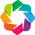

In [20]:
import matplotlib.pyplot as plt
import pickle
import dill
import holoviews as hv
import panel as pn

# IMPORTANT: initialize HoloViews with the bokeh backend FIRST,
# then call pn.extension() with NO positional arguments.
# pn.extension('bokeh') does NOT work in Panel >= 1.0 — 'bokeh' is not
# a recognized Panel JS extension name and the call silently skips
# backend initialization, which prevents the interactive dashboard
# from rendering.
hv.extension('bokeh')
pn.extension()

from scaleMAP.loader import load_scalemap_h5
from scaleMAP.preprocessing import (
    spectral_concat, zscore_normalize, apply_background_mask,
    build_peak_descriptor, normalize_peak_descriptor,
)
from scaleMAP.pipeline import (
    run_scalemap_pipeline, make_cache_path,
    fit_reference, transform_into_reference, load_reference_bundle,
)
from visualizer.visualizer import (
    generate_freehand_overlay_spectrum_2, flatten_image, extract_lasso_mask,
    generate_peak_explorer,
)
from visualizer.clustering import (
    kmeanscluster, plot_kmeans_clusters, cluster_colors,
    generate_cluster_explorer,
)

## Load

In [21]:
# Load data — supports both CASCADE HDF5 and legacy CRIkit pickle.
#
# Spectral mode can use either source:
#   - PICKLE_FILE_PATH (CRIkit .pickle): loads stdimg (x,y,a) + stdfreq (a,)
#   - H5_FILE_PATH (CASCADE HDF5):       loads model_cube (x,y,a) + x_axis (a,)
#
# Peak-params mode always requires H5_FILE_PATH (peak_params_cube only in HDF5).

if ANALYSIS_MODE == 'spectral' and PICKLE_FILE_PATH is not None:
    with open(PICKLE_FILE_PATH, 'rb') as _f:
        _loaded = pickle.load(_f)
    model_cube       = _loaded['stdimg']    # shape (x, y, a)
    x_axis           = _loaded['stdfreq']   # shape (a,)
    peak_params_cube = None
    max_peaks        = 0
    print(f'Loaded from pickle: {PICKLE_FILE_PATH}')
else:
    data = load_scalemap_h5(H5_FILE_PATH)
    model_cube       = data['model_cube']        # shape (x, y, a)
    peak_params_cube = data['peak_params_cube']  # shape (x, y, b)
    x_axis           = data['x_axis']            # shape (a,) or None
    max_peaks        = data['max_peaks']         # int (derived from the file, never hardcoded)
    print(f'Loaded from HDF5: {H5_FILE_PATH}')

rows, cols = model_cube.shape[0], model_cube.shape[1]
n_pixels = rows * cols
print(f'Image: {rows}x{cols}, {model_cube.shape[2]} spectral channels, {max_peaks} peak slots')
if x_axis is not None:
    print(f'Measured axis: {float(np.min(x_axis)):.0f}–{float(np.max(x_axis)):.0f} cm⁻¹')

Loaded from HDF5: /Volumes/edrive/bcars-imaging/shi/2025.09.15/peak-fit-pub/fitted_differentiated_segmented.h5
Image: 385x500, 547 spectral channels, 54 peak slots
Measured axis: 600–1709 cm⁻¹


## QC

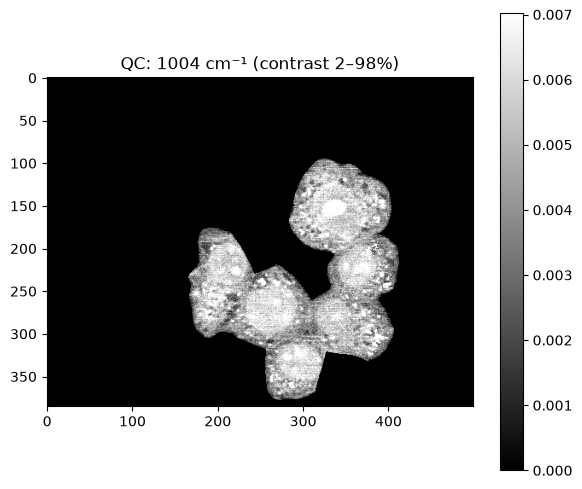

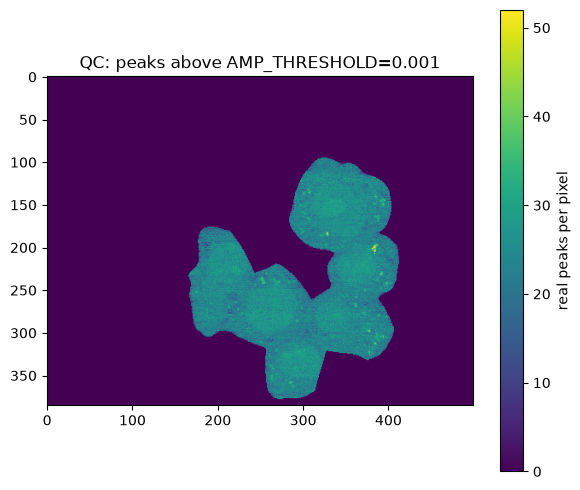

Peak count range: 0–52 (median 0); 154308 zero-peak (background) pixels


In [22]:
# Quick sanity checks before committing to a long fit.
# QC channel: nearest to QC_WAVENUMBER when an x_axis is available, with
# percentile-clipped contrast so a low-contrast channel is still readable.
if x_axis is not None and QC_WAVENUMBER is not None:
    _ax = np.asarray(x_axis)
    if not (_ax.min() <= QC_WAVENUMBER <= _ax.max()):
        print(f'NOTE: QC_WAVENUMBER={QC_WAVENUMBER:g} is outside the measured '
              f'axis ({_ax.min():.0f}–{_ax.max():.0f} cm⁻¹); showing the '
              'nearest available channel instead.')
    _qc_idx = int(np.argmin(np.abs(_ax - QC_WAVENUMBER)))
    _qc_label = f'{float(_ax[_qc_idx]):.0f} cm⁻¹'
else:
    _qc_idx = model_cube.shape[2] // 2
    _qc_label = f'channel {_qc_idx}'

_qc_img = model_cube[:, :, _qc_idx]
_vmin, _vmax = np.percentile(_qc_img, QC_CONTRAST_PERCENTILES)
plt.figure(figsize=(6, 5))
plt.imshow(_qc_img, cmap='gray', vmin=_vmin, vmax=_vmax)
plt.colorbar()
plt.title(f'QC: {_qc_label} '
          f'(contrast {QC_CONTRAST_PERCENTILES[0]:g}–{QC_CONTRAST_PERCENTILES[1]:g}%)')
plt.tight_layout()
plt.show()

if ANALYSIS_MODE == 'peak_params':
    # Real peaks per pixel (amplitude slots are every 4th value starting at 0).
    n_real_peaks = (peak_params_cube[..., 0::4] > AMP_THRESHOLD).sum(axis=2)
    plt.figure(figsize=(6, 5))
    plt.imshow(n_real_peaks, cmap='viridis')
    plt.colorbar(label='real peaks per pixel')
    plt.title(f'QC: peaks above AMP_THRESHOLD={AMP_THRESHOLD:g}')
    plt.tight_layout()
    plt.show()
    print(f'Peak count range: {n_real_peaks.min()}–{n_real_peaks.max()} '
          f'(median {int(np.median(n_real_peaks))}); '
          f'{int((n_real_peaks == 0).sum())} zero-peak (background) pixels')

## Preprocess

In [23]:
# Build the feature matrix X (n_pixels, n_features), raster (row-major) order,
# and the automatic foreground mask: in peak mode, pixels with ZERO real peaks
# are segmented background and are dropped from every analysis pass.
if ANALYSIS_MODE == 'spectral':
    # Keep only the ranges the measured axis actually covers (a peak-fit .h5
    # stops near 1800 cm⁻¹, so the CH-stretch range only applies to .pickle
    # data that extends past 2750).
    _ranges, _scales = [], []
    for (_lo, _hi), _sf in zip(SPECTRAL_RANGES, SPECTRAL_SCALE_FACTORS):
        if x_axis is not None and (_lo >= float(np.max(x_axis))
                                   or _hi <= float(np.min(x_axis))):
            print(f'Skipping spectral range ({_lo:g}, {_hi:g}) cm⁻¹ — outside '
                  f'the measured axis ({float(np.min(x_axis)):.0f}–'
                  f'{float(np.max(x_axis)):.0f} cm⁻¹).')
            continue
        _ranges.append((_lo, _hi))
        _scales.append(_sf)
    if not _ranges:
        raise ValueError('No SPECTRAL_RANGES overlap the measured axis.')
    print(f'Spectral ranges used: {_ranges} with scale factors {_scales}')

    hsi_concat = spectral_concat(
        model_cube, _ranges, scale_factors=_scales, x_axis=x_axis,
    )
    X = zscore_normalize(flatten_image(hsi_concat), epsilon=ZSCORE_EPSILON)
    peak_norm_stats = None
    foreground_flat = np.ones(n_pixels, dtype=bool)
elif ANALYSIS_MODE == 'peak_params':
    # Canonical, permutation-invariant, image-independent descriptor: every
    # real peak rendered as a pseudo-Voigt onto DESCRIPTOR_GRID and summed.
    D = build_peak_descriptor(
        peak_params_cube, x_axis,
        amp_threshold=AMP_THRESHOLD, grid=DESCRIPTOR_GRID,
        sigma_render=SIGMA_RENDER,
    )
    if EMBED_ROLE == 'transform_into_reference':
        # A transformed image must be normalized exactly like its reference:
        # replay the stats persisted in the reference bundle.
        _ref_bundle = load_reference_bundle(
            REFERENCE_BUNDLE_PATH,
            expected_grid=DESCRIPTOR_GRID, expected_amp_threshold=AMP_THRESHOLD,
        )
        X, peak_norm_stats = normalize_peak_descriptor(
            D, mode='reference', stats=_ref_bundle['norm_stats'])
    else:
        X, peak_norm_stats = normalize_peak_descriptor(D, mode=PEAK_NORM_MODE)
    print(f'Descriptor: {D.shape}, normalization stats: {peak_norm_stats}')

    if EXCLUDE_ZERO_PEAK_PIXELS:
        _n_real_flat = (peak_params_cube[..., 0::4] > AMP_THRESHOLD).sum(axis=2).reshape(-1)
        foreground_flat = _n_real_flat > 0
        if not foreground_flat.any():
            raise ValueError(
                'Every pixel has zero real peaks — check AMP_THRESHOLD and the input file.')
        print(f'Auto-excluded {int((~foreground_flat).sum())} zero-peak background pixels '
              f'({foreground_flat.sum()} foreground pixels retained)')
    else:
        foreground_flat = np.ones(n_pixels, dtype=bool)
else:
    raise ValueError(
        f"Invalid ANALYSIS_MODE: '{ANALYSIS_MODE}'. Must be 'spectral' or 'peak_params'."
    )

X_fg = X[foreground_flat]
pixel_indices_fg = np.flatnonzero(foreground_flat)
print(f'Feature matrix X: {X.shape}; analyzed (foreground): {X_fg.shape}')

Descriptor: (192500, 1500), normalization stats: {'mode': 'l1_per_pixel'}
Auto-excluded 154308 zero-peak background pixels (38192 foreground pixels retained)
Feature matrix X: (192500, 1500); analyzed (foreground): (38192, 1500)


## UMAP (full image, foreground pixels)

In [24]:
# Every UMAP construction is seeded (RANDOM_STATE) so repeated fits on
# identical input are identical.
umap_kwargs = dict(
    n_components=2,
    n_neighbors=UMAP_N_NEIGHBORS,
    min_dist=UMAP_MIN_DIST,
    n_epochs=UMAP_N_EPOCHS,
    densmap=UMAP_DENSMAP,
    dens_frac=UMAP_DENS_FRAC,
    random_state=RANDOM_STATE,
    verbose=True,
)

if ANALYSIS_MODE == 'peak_params':
    # Standard named metric on the normalized descriptor (cosine by default),
    # so ParametricUMAP/AlignedUMAP transforms and NNDescent fast paths work.
    umap_kwargs['metric'] = PEAK_METRIC

    if EMBED_ROLE == 'fit_reference':
        # Fit this image as the shared reference frame and persist a
        # self-describing bundle (model/descriptors + norm stats + grid +
        # amp_threshold + seed + hyperparameters).
        embedding_full, reference_bundle = fit_reference(
            X_fg, REFERENCE_BUNDLE_PATH, umap_kwargs,
            grid=DESCRIPTOR_GRID, amp_threshold=AMP_THRESHOLD,
            norm_stats=peak_norm_stats, transform_backend=TRANSFORM_BACKEND,
            embedding_cache_path=make_cache_path(
                SAVEFILE_BASENAME, ANALYSIS_MODE, 'reference', f'full{_FG_TAG}'),
        )
    elif EMBED_ROLE == 'transform_into_reference':
        # Place this image into the persisted reference frame — no fresh fit.
        # Bundle grid/amp_threshold/version mismatches raise.
        embedding_full = transform_into_reference(
            X_fg, REFERENCE_BUNDLE_PATH,
            grid=DESCRIPTOR_GRID, amp_threshold=AMP_THRESHOLD,
            cache_path=make_cache_path(
                SAVEFILE_BASENAME, ANALYSIS_MODE, 'transformed', f'full{_FG_TAG}'),
        )
    else:
        raise ValueError(
            f"Invalid EMBED_ROLE: '{EMBED_ROLE}'. "
            "Must be 'fit_reference' or 'transform_into_reference'."
        )
else:
    savepath_full = make_cache_path(SAVEFILE_BASENAME, ANALYSIS_MODE, 'standalone')
    embedding_full, model_full = run_scalemap_pipeline(X_fg, savepath_full, umap_kwargs)

print(f'Embedding shape: {embedding_full.shape} '
      f'({len(pixel_indices_fg)} foreground pixels)')

/opt/anaconda3/envs/csmap/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


UMAP(angular_rp_forest=True, low_memory=False, metric='cosine', n_epochs=200, n_jobs=1, random_state=42, verbose=True)
Wed Jul 15 09:30:59 2026 Construct fuzzy simplicial set
Wed Jul 15 09:30:59 2026 Finding Nearest Neighbors
Wed Jul 15 09:30:59 2026 Building RP forest with 14 trees
Wed Jul 15 09:31:00 2026 NN descent for 15 iterations
	 1  /  15
	 2  /  15
	 3  /  15
	 4  /  15
	 5  /  15
	Stopping threshold met -- exiting after 5 iterations
Wed Jul 15 09:31:03 2026 Finished Nearest Neighbor Search
Wed Jul 15 09:31:05 2026 Construct embedding


Epochs completed:   0%|            0/200 [00:00]

	completed  0  /  200 epochs
	completed  20  /  200 epochs
	completed  40  /  200 epochs
	completed  60  /  200 epochs
	completed  80  /  200 epochs
	completed  100  /  200 epochs
	completed  120  /  200 epochs
	completed  140  /  200 epochs
	completed  160  /  200 epochs
	completed  180  /  200 epochs
Wed Jul 15 09:31:15 2026 Finished embedding


/opt/anaconda3/envs/csmap/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


UMAP(angular_rp_forest=True, low_memory=False, metric='cosine', n_epochs=200, n_jobs=1, random_state=42, verbose=True)
Wed Jul 15 09:31:15 2026 Construct fuzzy simplicial set
Wed Jul 15 09:31:15 2026 Finding Nearest Neighbors
Wed Jul 15 09:31:15 2026 Building RP forest with 15 trees
Wed Jul 15 09:31:17 2026 NN descent for 15 iterations
	 1  /  15
	 2  /  15
	 3  /  15
	 4  /  15
	Stopping threshold met -- exiting after 4 iterations
Wed Jul 15 09:31:20 2026 Finished Nearest Neighbor Search
Wed Jul 15 09:31:20 2026 Construct embedding


Epochs completed:   0%|            0/200 [00:00]

	completed  0  /  200 epochs
	completed  20  /  200 epochs
	completed  40  /  200 epochs
	completed  60  /  200 epochs
	completed  80  /  200 epochs
	completed  100  /  200 epochs
	completed  120  /  200 epochs
	completed  140  /  200 epochs
	completed  160  /  200 epochs
	completed  180  /  200 epochs
Wed Jul 15 09:31:32 2026 Finished embedding
Embedding shape: (38192, 2) (38192 foreground pixels)


## Dashboard (full image)

Pens 1–2 (blue/orange strokes) draw on the embedding panel; pens 3–4 on the
image panel — arm the one you want from its toolbar (hover for names). Both
pens of each panel cross-highlight the other panel: embedding pens paint the
image electric blue / hot red; image pens paint the embedding light blue /
deep orange. Each pen's spectrum below is drawn in the pen's stroke color.
**Embedding pen 1** is the primary background/foreground lasso for the next
step.

In [25]:
dashboard_full = generate_freehand_overlay_spectrum_2(
    model_cube,
    embedding_full,
    spectrum_x_axis=x_axis,
    pixel_indices=pixel_indices_fg,
)
dashboard_full

Column
    [0] HoloViews(Layout)
    [1] Row
        [0] Row
            [0] StaticText(label='Choose dispersion mode', name='Choose dispersion mode', styles={'align-self': 'center'})
            [1] RadioBoxGroup(inline=True, label='dispersion', name='dispersion', options=['None', 'Std', 'MinMax'], styles={'align-self': 'center'}, value='None', width=175)
            [2] StaticText(label='Update', name='Update', styles={'align-self': 'center'})
            [3] Button(label='Points 1', name='Points 1', styles={'align-self': 'center'}, width=50)
            [4] Button(label='Points 2', name='Points 2', styles={'align-self': 'center'}, width=50)
            [5] Button(label='Image 1', name='Image 1', styles={'align-self': 'center'}, width=50)
            [6] Button(label='Image 2', name='Image 2', styles={'align-self': 'center'}, width=50)
        [1] RangeSlider(end=100.0, label='Image contrast (..., name='Image contrast (..., step=0.5, styles={'align-self': 'center'}, value=(1.0, 99.0), value_end=99.0, value_start=1.0, width=300)
    [2] HoloViews(Layout)
    [3] Row
        [0] StaticText(label='Copy', name='Copy', styles={'align-self': 'center'})
        [1] Toggle(button_type='primary', color='primary', label='Include dispersion (±)', name='Include dispersion (±)', styles={'align-self': 'center'}, width=150)
        [2] Button(label='X_axis', name='X_axis', styles={'align-self': 'center'}, width=50)
        [3] Button(label='Points 1', name='Points 1', styles={'align-self': 'center'}, width=50)
        [4] Button(label='Points 2', name='Points 2', styles={'align-self': 'center'}, width=50)
        [5] Button(label='Image 1', name='Image 1', styles={'align-self': 'center'}, width=50)
        [6] Button(label='Image 2', name='Image 2', styles={'align-self': 'center'}, width=50)

## Background mask

In [11]:
# Read the committed lasso from the dashboard above. The EMBEDDING-panel
# lasso ('Embedding pen 1') takes precedence — circling the background
# cluster in embedding space is usually easier than tracing it in the image.
# An image-panel lasso ('Image pen 1') is honored otherwise. Zero-peak
# background pixels are excluded automatically either way. Re-run this cell
# after drawing.
if SKIP_BACKGROUND_STEP:
    background_mask_flat = np.zeros(n_pixels, dtype=bool)
    print('SKIP_BACKGROUND_STEP=True: skipping background lasso selection.')
else:
    background_mask_flat = extract_lasso_mask(dashboard_full, panel='embedding', slot=1)
    if not background_mask_flat.any():
        background_mask_flat = extract_lasso_mask(dashboard_full, panel='image', slot=1)
    if not background_mask_flat.any():
        print("No committed lasso found. Draw with 'Embedding pen 1' or "
              "'Image pen 1' on the dashboard above, then re-run this cell.")

print(f'background_mask_flat shape: {background_mask_flat.shape}, '
      f'n_marked: {int(background_mask_flat.sum())}')

SKIP_BACKGROUND_STEP=True: skipping background lasso selection.
background_mask_flat shape: (192000,), n_marked: 0


## Masked UMAP

In [14]:
if SKIP_BACKGROUND_STEP:
    # All-retain (beyond the automatic zero-peak exclusion): reuse the
    # foreground embedding.
    keep_flat = foreground_flat.copy()
    X_masked = X_fg
    embedding_masked = embedding_full
    print('SKIP_BACKGROUND_STEP=True: reusing foreground embedding.')
else:
    _lasso_keep = (~background_mask_flat if MASK_MODE == 'exclude_background'
                   else background_mask_flat)
    keep_flat = foreground_flat & _lasso_keep
    X_masked = apply_background_mask(X, keep_flat, 'include_foreground')
    if X_masked.shape[0] == 0:
        raise ValueError(
            f"The mask retains zero pixels with MASK_MODE='{MASK_MODE}'. "
            "Check that the lasso selection and MASK_MODE are consistent."
        )
    print(f'X_masked shape: {X_masked.shape} ({X_masked.shape[0]} pixels retained)')

    if ANALYSIS_MODE == 'peak_params':
        if EMBED_ROLE == 'fit_reference':
            embedding_masked, reference_bundle_masked = fit_reference(
                X_masked, REFERENCE_BUNDLE_MASKED_PATH, umap_kwargs,
                grid=DESCRIPTOR_GRID, amp_threshold=AMP_THRESHOLD,
                norm_stats=peak_norm_stats, transform_backend=TRANSFORM_BACKEND,
                embedding_cache_path=make_cache_path(
                    SAVEFILE_BASENAME, ANALYSIS_MODE, 'reference', f'masked{_FG_TAG}'),
            )
        else:
            # Requires the reference image's masked bundle (created when the
            # reference itself was processed with its background mask).
            embedding_masked = transform_into_reference(
                X_masked, REFERENCE_BUNDLE_MASKED_PATH,
                grid=DESCRIPTOR_GRID, amp_threshold=AMP_THRESHOLD,
                cache_path=make_cache_path(
                    SAVEFILE_BASENAME, ANALYSIS_MODE, 'transformed', f'masked{_FG_TAG}'),
            )
    else:
        savepath_masked = make_cache_path(
            SAVEFILE_BASENAME, ANALYSIS_MODE, 'standalone', 'masked')
        embedding_masked, model_masked = run_scalemap_pipeline(
            X_masked, savepath_masked, umap_kwargs)

pixel_indices_masked = np.flatnonzero(keep_flat)
if embedding_masked.shape[0] != pixel_indices_masked.shape[0]:
    raise RuntimeError(
        f'Masked embedding has {embedding_masked.shape[0]} rows but '
        f'{pixel_indices_masked.shape[0]} pixels are retained — a stale '
        'cache slipped through; delete the masked cache files and re-run.')
print(f'Masked embedding shape: {embedding_masked.shape}')

SKIP_BACKGROUND_STEP=True: reusing foreground embedding.
Masked embedding shape: (30550, 2)


## Final dashboard (masked)

In [15]:
dashboard_masked = generate_freehand_overlay_spectrum_2(
    model_cube,           # always the full model_cube for spectral extraction
    embedding_masked,
    spectrum_x_axis=x_axis,
    pixel_indices=pixel_indices_masked,
)
dashboard_masked

Column
    [0] HoloViews(Layout)
    [1] Row
        [0] Row
            [0] StaticText(label='Choose dispersion mode', name='Choose dispersion mode', styles={'align-self': 'center'})
            [1] RadioBoxGroup(inline=True, label='dispersion', name='dispersion', options=['None', 'Std', 'MinMax'], styles={'align-self': 'center'}, value='None', width=175)
            [2] StaticText(label='Update', name='Update', styles={'align-self': 'center'})
            [3] Button(label='Points 1', name='Points 1', styles={'align-self': 'center'}, width=50)
            [4] Button(label='Points 2', name='Points 2', styles={'align-self': 'center'}, width=50)
            [5] Button(label='Image 1', name='Image 1', styles={'align-self': 'center'}, width=50)
            [6] Button(label='Image 2', name='Image 2', styles={'align-self': 'center'}, width=50)
        [1] RangeSlider(end=100.0, label='Image contrast (..., name='Image contrast (..., step=0.5, styles={'align-self': 'center'}, value=(1.0, 99.0), value_end=99.0, value_start=1.0, width=300)
    [2] HoloViews(Layout)
    [3] Row
        [0] StaticText(label='Copy', name='Copy', styles={'align-self': 'center'})
        [1] Toggle(button_type='primary', color='primary', label='Include dispersion (±)', name='Include dispersion (±)', styles={'align-self': 'center'}, width=150)
        [2] Button(label='X_axis', name='X_axis', styles={'align-self': 'center'}, width=50)
        [3] Button(label='Points 1', name='Points 1', styles={'align-self': 'center'}, width=50)
        [4] Button(label='Points 2', name='Points 2', styles={'align-self': 'center'}, width=50)
        [5] Button(label='Image 1', name='Image 1', styles={'align-self': 'center'}, width=50)
        [6] Button(label='Image 2', name='Image 2', styles={'align-self': 'center'}, width=50)

## Peak explorer

Which pixels contain a peak at a given wavenumber?  Tap a bar in the peak-center
histogram (or drag the slider) to see the spatial map of pixels whose fitted
peak set includes a center within ± the tolerance, colored by that peak's
amplitude. Contrast auto-scales to the current selection; raise **Color gain**
to saturate weak peaks into visibility (saturated pixels show pale yellow), or
switch the color scale to `eq_hist`/`log`.

In [12]:
if ANALYSIS_MODE == 'peak_params':
    peak_explorer = generate_peak_explorer(
        peak_params_cube, x_axis=x_axis, amp_threshold=AMP_THRESHOLD,
    )
else:
    peak_explorer = pn.pane.Markdown(
        'Peak explorer requires `ANALYSIS_MODE = "peak_params"`.')
peak_explorer

Column
    [0] Row
        [0] FloatSlider(end=1708.6768798828125, label='Peak center wavenumber', name='Peak center wavenumber', start=599.7218017578125, step=1.108955078125, value=854.781494140625, width=380)
        [1] FloatSlider(end=100.0, label='Center tolerance (±)', name='Center tolerance (±)', start=0.5, step=0.5, value=10.0, width=280)
    [1] Row
        [0] FloatSlider(end=50.0, label='Color gain (×)', name='Color gain (×)', start=1.0, step=0.5, value=1.0, width=280)
        [1] Select(label='Color scale', name='Color scale', options=['linear', 'log', ...], value='eq_hist', width=120)
    [2] HoloViews(Layout)

## KMeans (static)

Clusters are computed on the retained (foreground, masked) pixels only, using
`KMEANS_FEATURES` — the peak `descriptor` by default in peak mode, so the
clustering separates on peak profiles; `model_cube` spectra are percentile-
clipped (`KMEANS_CLIP_PERCENTILES`) before z-scoring so weird outlier pixels
can't dominate. Exactly `N_CLUSTERS` colors are shown; excluded pixels are
gray. The second figure shows each cluster's mean `model_cube` spectrum.

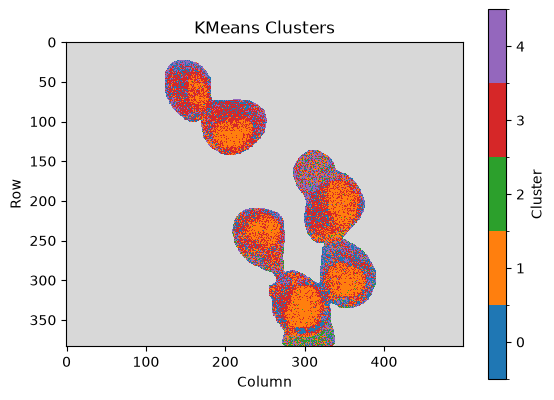

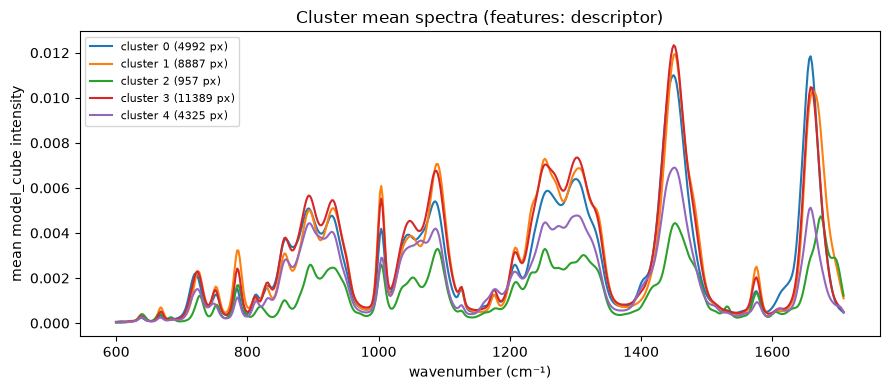

In [16]:
_kmeans_features = KMEANS_FEATURES
if _kmeans_features == 'descriptor' and ANALYSIS_MODE != 'peak_params':
    print("KMEANS_FEATURES='descriptor' needs peak mode — falling back to 'model_cube'.")
    _kmeans_features = 'model_cube'

if _kmeans_features == 'model_cube':
    _kmeans_X = zscore_normalize(
        flatten_image(model_cube)[pixel_indices_masked],
        epsilon=ZSCORE_EPSILON, clip_percentiles=KMEANS_CLIP_PERCENTILES)
elif _kmeans_features == 'descriptor':
    _kmeans_X = X[pixel_indices_masked]
elif _kmeans_features == 'embedding':
    _kmeans_X = embedding_masked
else:
    raise ValueError(
        f"Invalid KMEANS_FEATURES: '{KMEANS_FEATURES}'. "
        "Must be 'descriptor', 'model_cube', or 'embedding'."
    )

labels = kmeanscluster(_kmeans_X, n_clusters=N_CLUSTERS,
                       random_state=RANDOM_STATE)

# Scatter cluster labels back onto the full image grid; excluded pixels
# (auto background + lasso) get label -1 and render gray.
labels_full = np.full(n_pixels, -1, dtype=int)
labels_full[pixel_indices_masked] = labels
fig = plot_kmeans_clusters(labels_full, rows, cols)
plt.show()

# Mean model_cube spectrum per cluster, in matching colors.
_spec_x = np.asarray(x_axis) if x_axis is not None else np.arange(model_cube.shape[2])
_flat_cube = flatten_image(model_cube)
_colors = cluster_colors(N_CLUSTERS)
plt.figure(figsize=(9, 4))
for _k in range(N_CLUSTERS):
    _sel = pixel_indices_masked[labels == _k]
    if len(_sel):
        plt.plot(_spec_x, _flat_cube[_sel].mean(axis=0), color=_colors[_k],
                 label=f'cluster {_k} ({len(_sel)} px)')
plt.xlabel('wavenumber (cm⁻¹)' if x_axis is not None else 'channel')
plt.ylabel('mean model_cube intensity')
plt.legend(fontsize=8)
plt.title(f'Cluster mean spectra (features: {_kmeans_features})')
plt.tight_layout()
plt.show()

## Cluster explorer (interactive)

Re-run KMeans live: pick the feature source (peaks vs. spectra vs. embedding),
slide the cluster count (`N_CLUSTERS_EXPLORER` sets the start), and press
**Run clustering**. Shows the cluster map plus each cluster's mean spectrum
stacked waterfall-style in matching colors. Uses MiniBatchKMeans for speed —
use the static cell above for the final run.

Feature-source guide: **descriptor** clusters on peak *composition*
(recommended in peak mode); **model_cube** clusters on the full spectra
(robust-clipped + z-scored); **embedding** clusters on the 2-D UMAP
coordinates — fast and it matches what you *see* in the map, but it inherits
UMAP's distortions, so use it to label visual islands, not to discover
structure the embedding hasn't already shown.

In [17]:
_explorer_features = {}
if ANALYSIS_MODE == 'peak_params':
    _explorer_features['descriptor (peaks)'] = X[pixel_indices_masked]
_explorer_features['model_cube (spectra)'] = zscore_normalize(
    flatten_image(model_cube)[pixel_indices_masked],
    epsilon=ZSCORE_EPSILON, clip_percentiles=KMEANS_CLIP_PERCENTILES)
_explorer_features['embedding (2-D)'] = embedding_masked

cluster_explorer = generate_cluster_explorer(
    _explorer_features, model_cube, x_axis, pixel_indices_masked,
    n_clusters=N_CLUSTERS_EXPLORER, random_state=RANDOM_STATE,
)
cluster_explorer

Column
    [0] Row
        [0] Select(label='Cluster on', name='Cluster on', options=['descriptor (peaks)', ...], value='descriptor (peaks)', width=180)
        [1] IntSlider(end=15, label='N clusters', name='N clusters', start=2, value=5, width=220)
        [2] Button(button_type='primary', color='primary', label='Run clustering', name='Run clustering', width=140)
        [3] StaticText()
    [1] HoloViews(Layout, sizing_mode='fixed')